# Notebook to define and evaluate a U-Net with tuned hyperparams

## Set up

In [ ]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

In [ ]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from src.model_unet import UNet
from src.visualizations import visualize_predictions

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

In [4]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 4
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 15
BASE_FEATURES = 24
SAVE_PATH = "best_unet_combo.pth"

In [5]:
# Create Data Splits
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [6]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=False, augment_train=False)

In [7]:
# Sanity check
images, masks = next(iter(train_loader))
print(f"Batch images: {images.shape}")  # [B, 9, H, W]
print(f"Batch masks:  {masks.shape}")   # [B, H, W]
print(f"Mask range:   {masks.min()} – {masks.max()}")
print(images.device)


Batch images: torch.Size([4, 9, 512, 512])
Batch masks:  torch.Size([4, 512, 512])
Mask range:   0 – 4
cpu


In [ ]:
# Loss — ComboLoss (CE + Tversky)
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)

## Model definition and training

In [ ]:
# Model
model = UNet(
    in_channels=9, # include difference channels
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device) 

In [ ]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights,
                      ce_weight=0.3,
                      tversky_weight=0.7, tversky_alpha=0.85, tversky_beta=0.15, tversky_gamma=0.6,
                      num_classes=NUM_CLASSES).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay = 1e-4)

#scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=2e-4, steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS, pct_start=0.1, div_factor=10, final_div_factor=100)

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

In [ ]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True)


## Model eval

In [ ]:
plot_train_history(history)

In [ ]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=False)

UnboundLocalError: cannot access local variable 'pre' where it is not associated with a value

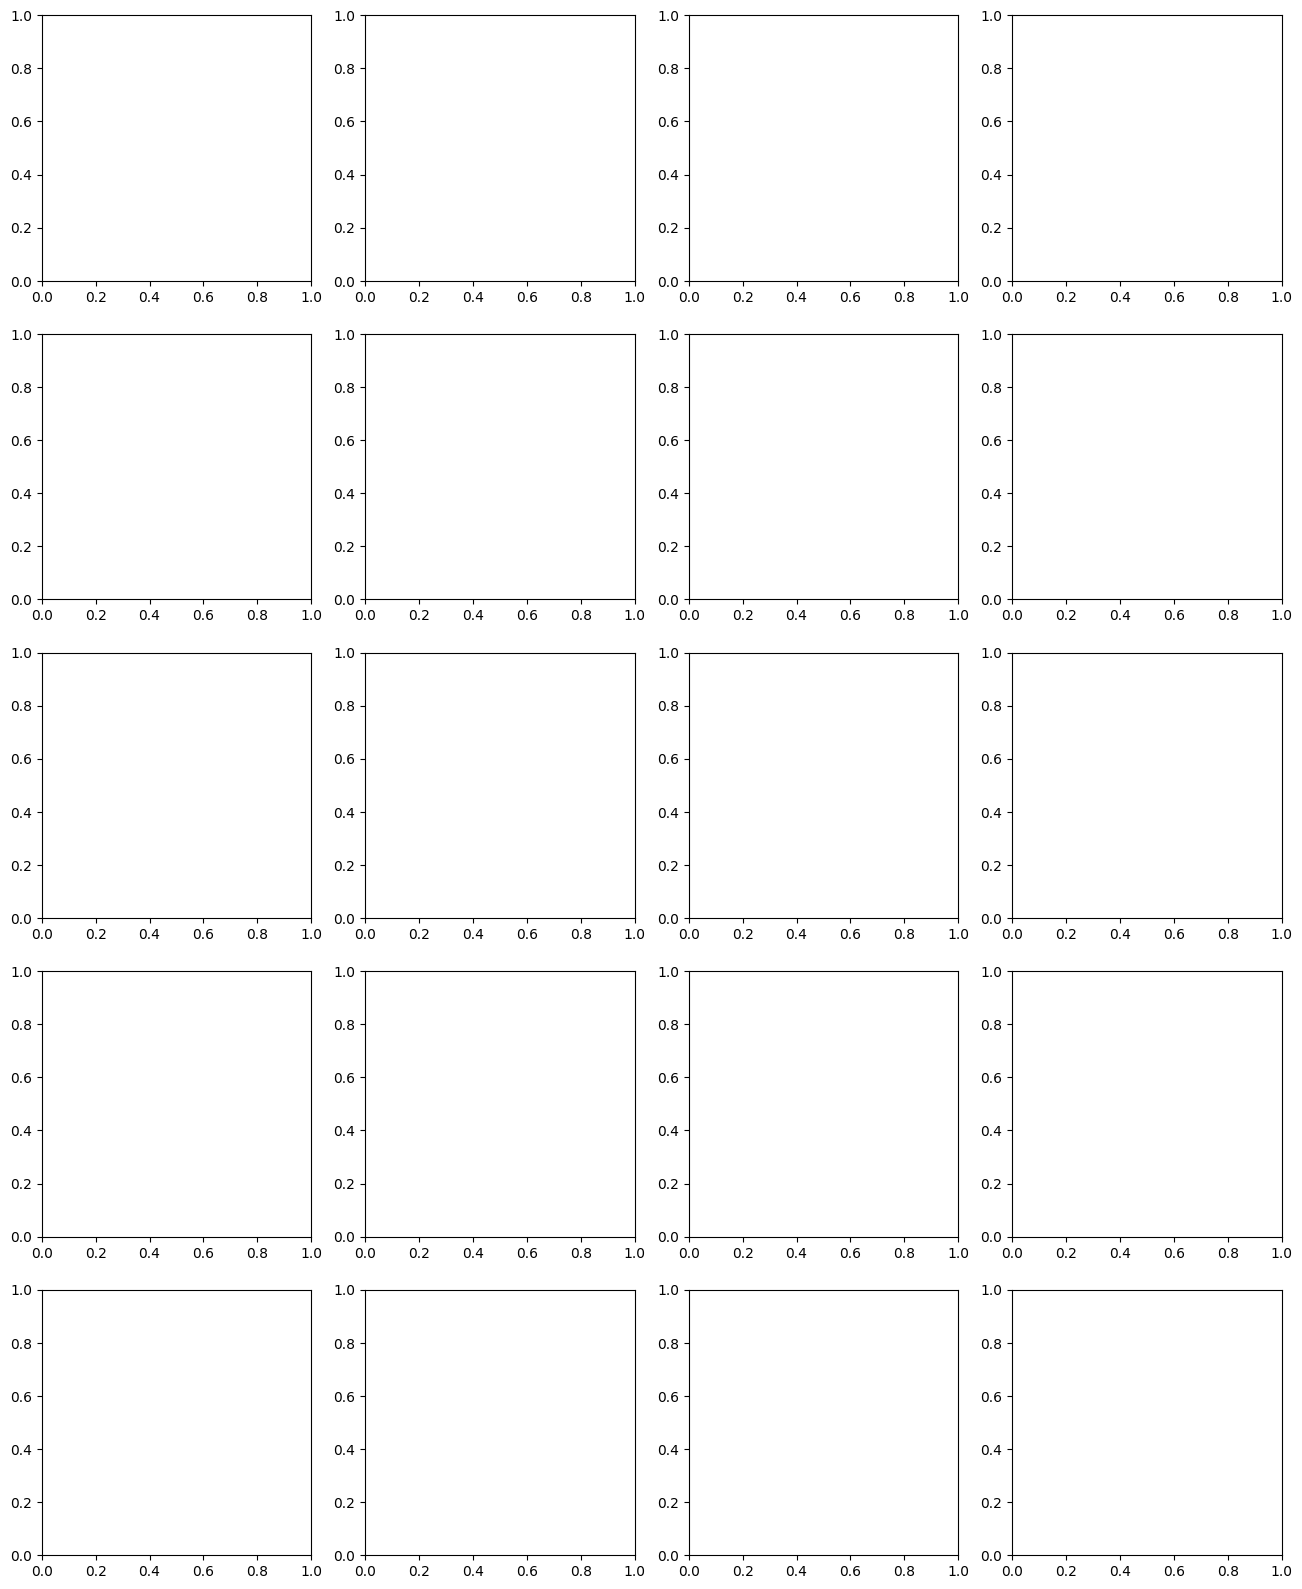

In [14]:
visualize_predictions(model=model, test_loader=test_loader, device=device,
    num_samples=5, title="Baseline U-Net Predictions", siamese=False)